In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
from IPython.display import FileLink

In [29]:
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        out = self.conv(x)
        out = self.relu(out)
        out = torch.cat([x, out], dim=1)
        return out

In [30]:
class ResidualDenseBlock(nn.Module):
    def __init__(self, in_channels, growth_rate=32, n_units=4):
        super(ResidualDenseBlock, self).__init__()
        
        self.units = nn.ModuleList()
        curr_channels = in_channels
        
        for _ in range(n_units):
            self.units.append(DenseLayer(curr_channels, growth_rate))
            curr_channels += growth_rate
        
        self.lff = nn.Conv2d(curr_channels, in_channels, kernel_size=1)
        
    def forward(self, x):
        residual = x
        out = x
        
        for unit in self.units:
            out = unit(out)
        
        out = self.lff(out)
        out = residual + out
        return out

class ResidualDenseBlockGroup(nn.Module):
    def __init__(self, in_channels, growth_rate=32, n_blocks=3, n_units_per_block=4):
        super(ResidualDenseBlockGroup, self).__init__()
        
        self.blocks = nn.ModuleList()
        for _ in range(n_blocks):
            self.blocks.append(ResidualDenseBlock(in_channels, growth_rate, n_units_per_block))
    
    def forward(self, x):
        out = x
        for block in self.blocks:
            out = block(out)
        return out

In [31]:
class MultiLevelRDN(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, growth_rate=32):
        super(MultiLevelRDN, self).__init__()
        
        self.initial_conv = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        
        self.level1_group = ResidualDenseBlockGroup(64, growth_rate, n_blocks=3)
        self.level2_group = ResidualDenseBlockGroup(64, growth_rate, n_blocks=3)
        self.level3_group = ResidualDenseBlockGroup(64, growth_rate, n_blocks=3)
        
        self.gff = nn.Sequential(
            nn.Conv2d(64 * 3, 64, kernel_size=1),
            nn.Conv2d(64, 64, kernel_size=3, padding=1)
        )
        
        self.output_conv = nn.Conv2d(64, out_channels, kernel_size=3, padding=1)
        self.global_skip = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        
    def forward(self, x):
        skip = self.global_skip(x)
        shallow = self.initial_conv(x)
        
        level1_out = self.level1_group(shallow)
        
        down_4x = F.interpolate(shallow, scale_factor=0.25, mode='bilinear', align_corners=False)
        level2_out = self.level2_group(down_4x)
        level2_out = F.interpolate(level2_out, size=shallow.shape[2:], mode='bilinear', align_corners=False)
        
        down_8x = F.interpolate(shallow, scale_factor=0.125, mode='bilinear', align_corners=False)
        level3_out = self.level3_group(down_8x)
        level3_out = F.interpolate(level3_out, size=shallow.shape[2:], mode='bilinear', align_corners=False)
        
        fused = torch.cat([level1_out, level2_out, level3_out], dim=1)
        fused = self.gff(fused)
        
        out = self.output_conv(fused)
        out = out + skip
        
        return out

In [32]:
class ResizedDataset(Dataset):
    def __init__(self, degraded_dir, pristine_dir, image_size=256):
        self.degraded_dir = degraded_dir
        self.pristine_dir = pristine_dir
        self.image_size = image_size
        
        degraded_extensions = ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tiff']
        self.degraded_paths = []
        for ext in degraded_extensions:
            self.degraded_paths.extend(glob(os.path.join(degraded_dir, ext)))
        
        self.degraded_paths = sorted(self.degraded_paths)
        
        self.pristine_paths = []
        for ext in degraded_extensions:
            self.pristine_paths.extend(glob(os.path.join(pristine_dir, ext)))
        
        self.pristine_paths = sorted(self.pristine_paths)
        
        self.pristine_dict = {}
        for p in self.pristine_paths:
            basename = os.path.splitext(os.path.basename(p))[0]
            self.pristine_dict[basename] = p
        
        matched_degraded = []
        matched_pristine = []
        
        for d in self.degraded_paths:
            basename = os.path.splitext(os.path.basename(d))[0]
            if basename in self.pristine_dict:
                matched_degraded.append(d)
                matched_pristine.append(self.pristine_dict[basename])
        
        self.degraded_paths = matched_degraded
        self.pristine_paths = matched_pristine
        
        print(f"Found {len(self.degraded_paths)} matched image pairs")
        print(f"All images will be resized to {image_size}x{image_size}")
        
    def __len__(self):
        return len(self.degraded_paths)
    
    def __getitem__(self, idx):
        degraded = Image.open(self.degraded_paths[idx]).convert('L')
        pristine = Image.open(self.pristine_paths[idx]).convert('L')
        
        degraded = degraded.resize((self.image_size, self.image_size), Image.BICUBIC)
        pristine = pristine.resize((self.image_size, self.image_size), Image.BICUBIC)
        
        if np.random.random() > 0.5:
            degraded = degraded.transpose(Image.FLIP_LEFT_RIGHT)
            pristine = pristine.transpose(Image.FLIP_LEFT_RIGHT)
        
        degraded = torch.from_numpy(np.array(degraded)).float().unsqueeze(0) / 255.0
        pristine = torch.from_numpy(np.array(pristine)).float().unsqueeze(0) / 255.0
        
        return degraded, pristine

In [33]:
def train_restoration_model(model, train_loader, val_loader, epochs=20, lr=0.001, device='cuda'):
    model = model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    criterion = nn.L1Loss()
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for batch_idx, (degraded, pristine) in enumerate(train_loader):
            degraded = degraded.to(device)
            pristine = pristine.to(device)
            
            optimizer.zero_grad()
            
            restored = model(degraded)
            loss = criterion(restored, pristine)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            if batch_idx % 200 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.6f}")
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for degraded, pristine in val_loader:
                degraded = degraded.to(device)
                pristine = pristine.to(device)
                restored = model(degraded)
                loss = criterion(restored, pristine)
                val_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        scheduler.step(avg_val_loss)
        
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {avg_train_loss:.6f}")
        print(f"  Val Loss: {avg_val_loss:.6f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}\n")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_restoration_model.pth')
            print(f"  ✓ Saved best model with val_loss: {best_val_loss:.6f}")
    
    return model

def visualize_restoration(model, dataset, device, num_samples=5):
    model.eval()
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4*num_samples))
    
    indices = list(range(min(num_samples, len(dataset))))
    
    for i, idx in enumerate(indices):
        degraded, pristine = dataset[idx]
        
        degraded = degraded.unsqueeze(0).to(device)
        
        with torch.no_grad():
            restored = model(degraded)
        
        degraded_np = degraded.squeeze().cpu().numpy()
        restored_np = restored.squeeze().cpu().numpy()
        pristine_np = pristine.squeeze().numpy()
        
        axes[i, 0].imshow(degraded_np, cmap='gray')
        axes[i, 0].set_title('Input (degraded)', fontsize=10)
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(restored_np, cmap='gray')
        axes[i, 1].set_title('Restored', fontsize=10)
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pristine_np, cmap='gray')
        axes[i, 2].set_title('Ground Truth', fontsize=10)
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('restoration_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    display(FileLink('restoration_results.png'))

In [35]:
if __name__ == "__main__":
    degraded_dir = r"/kaggle/input/datasets/artemsmorodskij/archive/landscape Images/gray"
    pristine_dir = r"/kaggle/input/datasets/artemsmorodskij/archive/landscape Images/color"
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")
    
    dataset = ResizedDataset(degraded_dir, pristine_dir, image_size=256)
    
    if len(dataset) == 0:
        print("ERROR: No matching image pairs found!")
    else:
        train_size = int(0.8 * len(dataset))
        val_size = len(dataset) - train_size
        train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
        
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
        
        model = MultiLevelRDN(in_channels=1, out_channels=1, growth_rate=32)
        
        total_params = sum(p.numel() for p in model.parameters())
        print(f"Total parameters: {total_params:,}")
        
        model = train_restoration_model(model, train_loader, val_loader, epochs=5, lr=0.001, device=device)

Using device: cuda
Found 8164 matched image pairs
All images will be resized to 256x256
Total parameters: 1,324,043
Epoch 1/5, Batch 0/409, Loss: 0.218032
Epoch 1/5, Batch 200/409, Loss: 0.024858
Epoch 1/5, Batch 400/409, Loss: 0.019050

Epoch 1/5
  Train Loss: 0.035489
  Val Loss: 0.016120
  LR: 0.001000

  ✓ Saved best model with val_loss: 0.016120
Epoch 2/5, Batch 0/409, Loss: 0.018084
Epoch 2/5, Batch 200/409, Loss: 0.018286
Epoch 2/5, Batch 400/409, Loss: 0.011196

Epoch 2/5
  Train Loss: 0.014881
  Val Loss: 0.012027
  LR: 0.001000

  ✓ Saved best model with val_loss: 0.012027
Epoch 3/5, Batch 0/409, Loss: 0.012391
Epoch 3/5, Batch 200/409, Loss: 0.011965
Epoch 3/5, Batch 400/409, Loss: 0.010215

Epoch 3/5
  Train Loss: 0.011760
  Val Loss: 0.010291
  LR: 0.001000

  ✓ Saved best model with val_loss: 0.010291
Epoch 4/5, Batch 0/409, Loss: 0.008716
Epoch 4/5, Batch 200/409, Loss: 0.010179
Epoch 4/5, Batch 400/409, Loss: 0.014571

Epoch 4/5
  Train Loss: 0.011275
  Val Loss: 0.0157

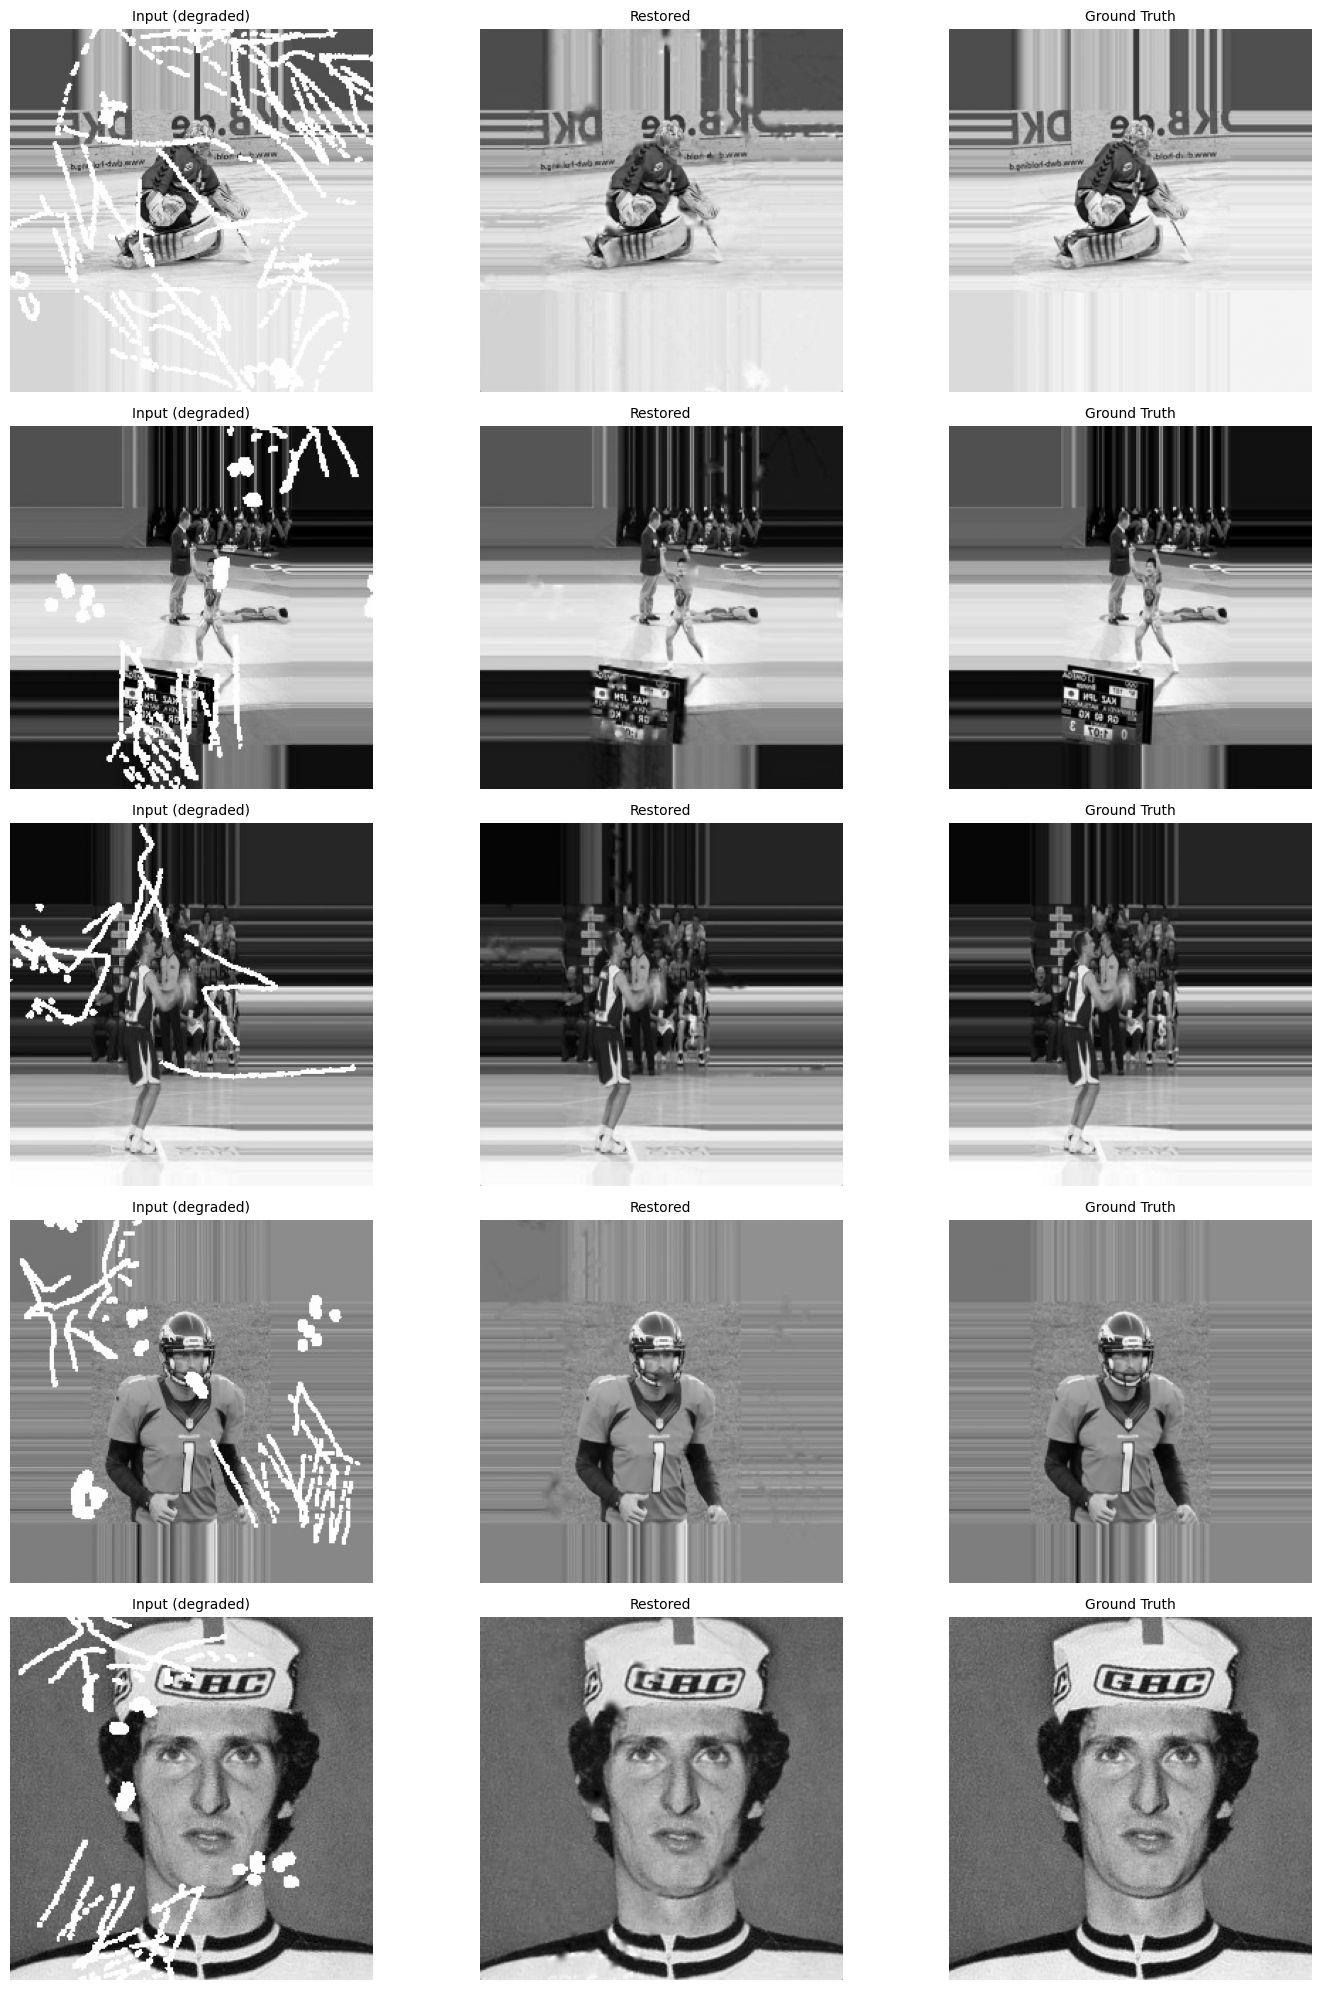

/kaggle/working/restoration_results.png


Final model saved as 'final_restoration_model.pth'


/kaggle/working/final_restoration_model.pth

In [36]:
visualize_restoration(model, val_dataset, device, num_samples=5)
        
torch.save(model.state_dict(), 'final_restoration_model.pth')
print("\nFinal model saved as 'final_restoration_model.pth'")
display(FileLink('final_restoration_model.pth'))